In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

print("ReturnShield environment ready!")

ReturnShield environment ready!


In [8]:
# ==========================================
# RETURNSHIELD - IMPROVED REALISTIC DATASET
# ==========================================

np.random.seed(42)

N = 10000

# 3,000 customers
customer_ids = np.arange(1, 3001)

# Give each customer a primary device.
# Most devices belong to one customer.
customer_device = {
    customer: 10000 + customer
    for customer in customer_ids
}

# Give customers realistic pincodes.
# Large range prevents accidental massive sharing.
customer_pincode = {
    customer: np.random.randint(560000, 570000)
    for customer in customer_ids
}

df = pd.DataFrame({
    "order_id": np.arange(100000, 100000 + N),

    "customer_id": np.random.choice(
        customer_ids,
        N
    ),

    "order_amount": np.round(
        np.random.lognormal(
            mean=7,
            sigma=0.7,
            size=N
        ),
        2
    ),

    "product_category": np.random.choice(
        [
            "Electronics",
            "Fashion",
            "Home",
            "Beauty",
            "Grocery"
        ],
        N,
        p=[0.25, 0.30, 0.20, 0.10, 0.15]
    ),

    "days_to_return": np.random.randint(
        1, 31, N
    ),

    "return_reason": np.random.choice(
        [
            "Damaged",
            "Wrong item",
            "Changed mind",
            "Not as expected"
        ],
        N
    ),

    "orders_last_30d": np.random.randint(
        2, 16, N
    ),

    "returns_last_30d": np.random.randint(
        0, 4, N
    )
})

# Assign normal customer relationships
df["device_id"] = df["customer_id"].map(
    customer_device
)

df["pincode"] = df["customer_id"].map(
    customer_pincode
)

# Returns cannot exceed orders
df["returns_last_30d"] = np.minimum(
    df["returns_last_30d"],
    df["orders_last_30d"]
)

# Ground truth
df["abuse_ring"] = 0

df["is_returned"] = (
    np.random.random(N) < 0.20
).astype(int)

df["customer_return_rate"] = (
    df["returns_last_30d"] /
    df["orders_last_30d"]
).round(3)

print("Improved dataset created:", df.shape)
print(
    "Maximum normal return rate:",
    df["customer_return_rate"].max()
)

Improved dataset created: (10000, 13)
Maximum normal return rate: 1.0


In [9]:
# ==========================================
# RETURNSHIELD - REALISTIC ABUSE RINGS
# ==========================================

NUM_RINGS = 15
RING_SIZE = 6

all_customers = df["customer_id"].unique()

for ring_id in range(NUM_RINGS):

    ring_customers = np.random.choice(
        all_customers,
        RING_SIZE,
        replace=False
    )

    # Special shared resources used by the synthetic ring
    shared_device = 20000 + ring_id

    shared_pincode = 570000 + ring_id

    for customer in ring_customers:

        mask = df["customer_id"] == customer

        # Coordinated relationship
        df.loc[mask, "device_id"] = shared_device
        df.loc[mask, "pincode"] = shared_pincode

        number_of_orders = mask.sum()

        if number_of_orders == 0:
            continue

        orders = np.random.randint(
            8,
            16,
            number_of_orders
        )

        returns = np.random.randint(
            5,
            9,
            number_of_orders
        )

        returns = np.minimum(
            returns,
            orders
        )

        df.loc[mask, "orders_last_30d"] = orders
        df.loc[mask, "returns_last_30d"] = returns

        # Very fast returns
        df.loc[mask, "days_to_return"] = np.random.randint(
            1,
            4,
            number_of_orders
        )

        # Similar product patterns
        df.loc[mask, "product_category"] = np.random.choice(
            ["Electronics", "Fashion"],
            number_of_orders
        )

        # Ground truth
        df.loc[mask, "abuse_ring"] = 1


df["customer_return_rate"] = (
    df["returns_last_30d"] /
    df["orders_last_30d"]
).round(3)

print("Abuse rings injected.")
print(
    "Abuse-ring records:",
    df["abuse_ring"].sum()
)

Abuse rings injected.
Abuse-ring records: 297


In [10]:
suspicious = df[df["abuse_ring"] == 1]

print("Suspicious records:", len(suspicious))

suspicious[
    [
        "customer_id",
        "device_id",
        "pincode",
        "order_amount",
        "product_category",
        "days_to_return",
        "orders_last_30d",
        "returns_last_30d",
        "customer_return_rate",
        "abuse_ring"
    ]
].head(20)

Suspicious records: 297


,customer_id,device_id,pincode,order_amount,product_category,days_to_return,orders_last_30d,returns_last_30d,customer_return_rate,abuse_ring
57,903,20012,570012,2060.79,Electronics,2,15,5,0.333,1
162,2079,20012,570012,1005.68,Fashion,1,15,7,0.467,1
196,1810,20003,570003,2173.91,Fashion,1,15,8,0.533,1
215,1698,20014,570014,1132.94,Electronics,1,14,5,0.357,1
218,2660,20010,570010,1268.85,Fashion,1,9,8,0.889,1
223,2225,20003,570003,376.93,Electronics,3,10,6,0.600,1
275,2079,20012,570012,335.14,Electronics,1,14,8,0.571,1
328,2278,20005,570005,260.60,Fashion,3,15,6,0.400,1
339,1698,20014,570014,574.23,Electronics,3,11,6,0.545,1
357,457,20011,570011,878.81,Electronics,2,12,5,0.417,1


In [11]:
df.to_csv("returnshield_dataset.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [12]:
# ==============================
# RETURNSHIELD - FEATURE ENGINE
# ==============================

df["return_intensity"] = (
    df["returns_last_30d"] /
    df["orders_last_30d"].clip(lower=1)
)

df["fast_return"] = (
    df["days_to_return"] <= 3
).astype(int)

df["high_return_behavior"] = (
    df["return_intensity"] >= 0.50
).astype(int)

# Number of customers sharing each device
device_customer_count = (
    df.groupby("device_id")["customer_id"]
    .nunique()
)

df["device_customer_count"] = (
    df["device_id"].map(device_customer_count)
)

# Number of customers sharing each pincode
pincode_customer_count = (
    df.groupby("pincode")["customer_id"]
    .nunique()
)

df["pincode_customer_count"] = (
    df["pincode"].map(pincode_customer_count)
)

print("Feature engineering complete.")

Feature engineering complete.


In [13]:
df["behavior_risk_score"] = (
    df["return_intensity"].clip(0, 1) * 30
    + df["fast_return"] * 15
    + (df["device_customer_count"] >= 3) * 25
    + (df["pincode_customer_count"] >= 5) * 15
    + (df["high_return_behavior"]) * 15
)

df["behavior_risk_score"] = (
    df["behavior_risk_score"].clip(0, 100).round(1)
)

df[
    [
        "customer_id",
        "device_id",
        "pincode",
        "return_intensity",
        "device_customer_count",
        "pincode_customer_count",
        "behavior_risk_score",
        "abuse_ring"
    ]
].sort_values(
    "behavior_risk_score",
    ascending=False
).head(20)

,customer_id,device_id,pincode,return_intensity,device_customer_count,pincode_customer_count,behavior_risk_score,abuse_ring
8910,2124,20004,570004,1.000000,5,5,100.0,1
5086,828,20007,570007,1.000000,6,6,100.0,1
9042,2323,20009,570009,1.000000,6,6,100.0,1
5907,234,20008,570008,1.000000,6,6,100.0,1
3063,2573,20002,570002,1.000000,6,6,100.0,1
3836,1918,20002,570002,1.000000,6,6,100.0,1
1013,242,20006,570006,1.000000,6,6,100.0,1
6503,2732,20014,570014,1.000000,6,6,100.0,1
1785,817,20003,570003,1.000000,6,6,100.0,1
9472,2143,20010,570010,0.888889,6,6,96.7,1


In [14]:
# Customers sharing the same device
shared_device = (
    df.groupby("device_id")["customer_id"]
    .nunique()
    .reset_index(name="customer_count")
)

suspicious_devices = shared_device[
    shared_device["customer_count"] >= 3
]

print(
    "Devices shared by 3+ customers:",
    len(suspicious_devices)
)

# Customers sharing the same pincode
shared_pincode = (
    df.groupby("pincode")["customer_id"]
    .nunique()
    .reset_index(name="customer_count")
)

suspicious_pincodes = shared_pincode[
    shared_pincode["customer_count"] >= 5
]

print(
    "Pincodes shared by 5+ customers:",
    len(suspicious_pincodes)
)

Devices shared by 3+ customers: 15
Pincodes shared by 5+ customers: 15


In [15]:
ring_candidates = df[
    (df["device_customer_count"] >= 3) &
    (df["pincode_customer_count"] >= 5) &
    (df["return_intensity"] >= 0.5)
]

print(
    "Potential coordinated-risk records:",
    len(ring_candidates)
)

ring_candidates[
    [
        "customer_id",
        "device_id",
        "pincode",
        "orders_last_30d",
        "returns_last_30d",
        "return_intensity",
        "device_customer_count",
        "pincode_customer_count",
        "behavior_risk_score"
    ]
].head(30)

Potential coordinated-risk records: 213


,customer_id,device_id,pincode,orders_last_30d,returns_last_30d,return_intensity,device_customer_count,pincode_customer_count,behavior_risk_score
196,1810,20003,570003,15,8,0.533333,6,6,86.0
218,2660,20010,570010,9,8,0.888889,6,6,96.7
223,2225,20003,570003,10,6,0.600000,6,6,88.0
275,2079,20012,570012,14,8,0.571429,6,6,87.1
339,1698,20014,570014,11,6,0.545455,6,6,86.4
455,1276,20004,570004,14,7,0.500000,5,5,85.0
563,947,20006,570006,9,5,0.555556,6,6,86.7
568,2451,20006,570006,10,7,0.700000,6,6,91.0
585,221,20012,570012,9,7,0.777778,6,6,93.3
602,2237,20000,570000,12,8,0.666667,6,6,90.0


In [16]:
!pip -q install networkx

In [17]:
import networkx as nx

print("NetworkX ready!")

NetworkX ready!


In [18]:
# ==========================================
# RETURNSHIELD - RELATIONSHIP GRAPH
# ==========================================

G = nx.Graph()

# Add customer-device-pincode relationships
for _, row in df.iterrows():

    customer = f"C_{row['customer_id']}"
    device = f"D_{row['device_id']}"
    pincode = f"P_{row['pincode']}"

    # Add nodes
    G.add_node(customer, node_type="customer")
    G.add_node(device, node_type="device")
    G.add_node(pincode, node_type="pincode")

    # Add relationships
    G.add_edge(customer, device, relationship="uses_device")
    G.add_edge(customer, pincode, relationship="located_at")

print("Graph created!")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Graph created!
Nodes: 8104
Edges: 5760


In [19]:
device_nodes = [
    node for node, data in G.nodes(data=True)
    if data["node_type"] == "device"
]

device_connections = []

for device in device_nodes:

    customers = [
        n for n in G.neighbors(device)
        if G.nodes[n]["node_type"] == "customer"
    ]

    device_connections.append({
        "device": device,
        "customer_count": len(customers),
        "customers": customers
    })

device_connections_df = pd.DataFrame(device_connections)

device_connections_df = device_connections_df.sort_values(
    "customer_count",
    ascending=False
)

device_connections_df.head(10)

,device,customer_count,customers
185,D_20003,6,"[C_1810, C_2225, C_128, C_817, C_1292, C_2570]"
535,D_20000,6,"[C_2237, C_1433, C_925, C_583, C_417, C_1870]"
1212,D_20008,6,"[C_447, C_1009, C_200, C_1619, C_234, C_1021]"
202,D_20014,6,"[C_1698, C_2411, C_244, C_182, C_2732, C_1886]"
205,D_20010,6,"[C_2660, C_1013, C_1787, C_545, C_2143, C_935]"
504,D_20006,6,"[C_947, C_2451, C_242, C_226, C_2185, C_1177]"
606,D_20002,6,"[C_167, C_1017, C_2573, C_157, C_2400, C_1918]"
971,D_20009,6,"[C_2667, C_1279, C_692, C_1536, C_2323, C_1923]"
770,D_20013,6,"[C_2425, C_1094, C_976, C_1716, C_2450, C_1176]"
56,D_20012,6,"[C_903, C_2079, C_221, C_2201, C_588, C_96]"


In [20]:
pincode_nodes = [
    node for node, data in G.nodes(data=True)
    if data["node_type"] == "pincode"
]

pincode_connections = []

for pincode in pincode_nodes:

    customers = [
        n for n in G.neighbors(pincode)
        if G.nodes[n]["node_type"] == "customer"
    ]

    pincode_connections.append({
        "pincode": pincode,
        "customer_count": len(customers),
        "customers": customers
    })

pincode_connections_df = pd.DataFrame(
    pincode_connections
).sort_values(
    "customer_count",
    ascending=False
)

pincode_connections_df.head(10)

,pincode,customer_count,customers
488,P_570006,6,"[C_947, C_2451, C_242, C_226, C_2185, C_1177]"
301,P_570005,6,"[C_2278, C_2147, C_1550, C_1256, C_1263, C_2358]"
578,P_570002,6,"[C_167, C_1017, C_2573, C_157, C_2400, C_1918]"
516,P_570000,6,"[C_2237, C_1433, C_925, C_583, C_417, C_1870]"
323,P_570011,6,"[C_457, C_2815, C_2340, C_1380, C_1182, C_1220]"
56,P_570012,6,"[C_903, C_2079, C_221, C_2201, C_588, C_96]"
185,P_570003,6,"[C_1810, C_2225, C_128, C_817, C_1292, C_2570]"
1283,P_570001,6,"[C_1233, C_1076, C_2003, C_2915, C_264, C_981]"
1127,P_570008,6,"[C_447, C_1009, C_200, C_1619, C_234, C_1021]"
915,P_570009,6,"[C_2667, C_1279, C_692, C_1536, C_2323, C_1923]"


In [21]:
ring_candidates = df[
    (df["device_customer_count"] >= 3) &
    (df["pincode_customer_count"] >= 5) &
    (df["return_intensity"] >= 0.50)
].copy()

print("Potential ring records:", len(ring_candidates))

ring_candidates[
    [
        "customer_id",
        "device_id",
        "pincode",
        "return_intensity",
        "device_customer_count",
        "pincode_customer_count",
        "behavior_risk_score",
        "abuse_ring"
    ]
].head(20)

Potential ring records: 213


,customer_id,device_id,pincode,return_intensity,device_customer_count,pincode_customer_count,behavior_risk_score,abuse_ring
196,1810,20003,570003,0.533333,6,6,86.0,1
218,2660,20010,570010,0.888889,6,6,96.7,1
223,2225,20003,570003,0.600000,6,6,88.0,1
275,2079,20012,570012,0.571429,6,6,87.1,1
339,1698,20014,570014,0.545455,6,6,86.4,1
455,1276,20004,570004,0.500000,5,5,85.0,1
563,947,20006,570006,0.555556,6,6,86.7,1
568,2451,20006,570006,0.700000,6,6,91.0,1
585,221,20012,570012,0.777778,6,6,93.3,1
602,2237,20000,570000,0.666667,6,6,90.0,1


In [22]:
# ==========================================
# RETURNSHIELD - RING DETECTION ENGINE
# ==========================================

# Shared device risk
df["device_risk"] = np.clip(
    (df["device_customer_count"] - 1) * 15,
    0,
    30
)

# Shared pincode risk
df["pincode_risk"] = np.clip(
    (df["pincode_customer_count"] - 1) * 5,
    0,
    20
)

# Return behavior risk
df["return_behavior_risk"] = np.clip(
    df["return_intensity"] * 30,
    0,
    30
)

# Fast-return risk
df["fast_return_risk"] = (
    (df["days_to_return"] <= 3).astype(int) * 20
)

print("Ring-level features calculated.")

Ring-level features calculated.


In [23]:
df["ring_risk_score"] = (
    df["device_risk"]
    + df["pincode_risk"]
    + df["return_behavior_risk"]
    + df["fast_return_risk"]
)

df["ring_risk_score"] = np.clip(
    df["ring_risk_score"],
    0,
    100
).round(1)

print("Risk scoring complete.")

Risk scoring complete.


In [24]:
def risk_decision(score):

    if score >= 75:
        return "HIGH RISK - INVESTIGATE"

    elif score >= 50:
        return "MEDIUM RISK - REVIEW"

    else:
        return "LOW RISK - MONITOR"


df["risk_decision"] = df["ring_risk_score"].apply(
    risk_decision
)

df[
    [
        "customer_id",
        "device_id",
        "pincode",
        "ring_risk_score",
        "risk_decision",
        "abuse_ring"
    ]
].sort_values(
    "ring_risk_score",
    ascending=False
).head(20)

,customer_id,device_id,pincode,ring_risk_score,risk_decision,abuse_ring
1785,817,20003,570003,100.0,HIGH RISK - INVESTIGATE,1
8910,2124,20004,570004,100.0,HIGH RISK - INVESTIGATE,1
5086,828,20007,570007,100.0,HIGH RISK - INVESTIGATE,1
1013,242,20006,570006,100.0,HIGH RISK - INVESTIGATE,1
9042,2323,20009,570009,100.0,HIGH RISK - INVESTIGATE,1
6503,2732,20014,570014,100.0,HIGH RISK - INVESTIGATE,1
5907,234,20008,570008,100.0,HIGH RISK - INVESTIGATE,1
3836,1918,20002,570002,100.0,HIGH RISK - INVESTIGATE,1
3063,2573,20002,570002,100.0,HIGH RISK - INVESTIGATE,1
218,2660,20010,570010,96.7,HIGH RISK - INVESTIGATE,1


In [25]:
def generate_explanation(row):

    reasons = []

    if row["device_customer_count"] >= 3:
        reasons.append(
            f"device shared by {int(row['device_customer_count'])} customers"
        )

    if row["pincode_customer_count"] >= 5:
        reasons.append(
            f"pincode linked to {int(row['pincode_customer_count'])} customers"
        )

    if row["return_intensity"] >= 0.50:
        reasons.append(
            f"high return intensity ({row['return_intensity']:.0%})"
        )

    if row["days_to_return"] <= 3:
        reasons.append(
            "returns occurring within 3 days"
        )

    if not reasons:
        return "No major coordinated-risk signals detected."

    return "; ".join(reasons)


df["risk_explanation"] = df.apply(
    generate_explanation,
    axis=1
)

In [26]:
top_risks = df.sort_values(
    "ring_risk_score",
    ascending=False
).head(15)

top_risks[
    [
        "customer_id",
        "device_id",
        "pincode",
        "ring_risk_score",
        "risk_decision",
        "risk_explanation",
        "abuse_ring"
    ]
]

,customer_id,device_id,pincode,ring_risk_score,risk_decision,risk_explanation,abuse_ring
1785,817,20003,570003,100.0,HIGH RISK - INVESTIGATE,device shared by 6 customers; pincode linked t...,1
8910,2124,20004,570004,100.0,HIGH RISK - INVESTIGATE,device shared by 5 customers; pincode linked t...,1
5086,828,20007,570007,100.0,HIGH RISK - INVESTIGATE,device shared by 6 customers; pincode linked t...,1
1013,242,20006,570006,100.0,HIGH RISK - INVESTIGATE,device shared by 6 customers; pincode linked t...,1
9042,2323,20009,570009,100.0,HIGH RISK - INVESTIGATE,device shared by 6 customers; pincode linked t...,1
6503,2732,20014,570014,100.0,HIGH RISK - INVESTIGATE,device shared by 6 customers; pincode linked t...,1
5907,234,20008,570008,100.0,HIGH RISK - INVESTIGATE,device shared by 6 customers; pincode linked t...,1
3836,1918,20002,570002,100.0,HIGH RISK - INVESTIGATE,device shared by 6 customers; pincode linked t...,1
3063,2573,20002,570002,100.0,HIGH RISK - INVESTIGATE,device shared by 6 customers; pincode linked t...,1
218,2660,20010,570010,96.7,HIGH RISK - INVESTIGATE,device shared by 6 customers; pincode linked t...,1


In [27]:
# ==========================================
# RETURNSHIELD - ML DATA PREPARATION
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Features used by the model
features = [
    "order_amount",
    "days_to_return",
    "orders_last_30d",
    "returns_last_30d",
    "return_intensity",
    "fast_return",
    "device_customer_count",
    "pincode_customer_count"
]

X = df[features].copy()
y = df["abuse_ring"].copy()

print("Feature matrix:", X.shape)
print("Target distribution:")
print(y.value_counts())

Feature matrix: (10000, 8)
Target distribution:
abuse_ring
0    9703
1     297
Name: count, dtype: int64


In [28]:
# ==========================================
# CUSTOMER-LEVEL TRAIN / TEST SPLIT
# ==========================================

customer_labels = (
    df[["customer_id", "abuse_ring"]]
    .drop_duplicates("customer_id")
)

train_customers, test_customers = train_test_split(
    customer_labels["customer_id"],
    test_size=0.25,
    random_state=42,
    stratify=customer_labels["abuse_ring"]
)

train_mask = df["customer_id"].isin(train_customers)
test_mask = df["customer_id"].isin(test_customers)

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("Training records:", len(X_train))
print("Testing records:", len(X_test))
print("Training customers:", len(train_customers))
print("Testing customers:", len(test_customers))

Training records: 7492
Testing records: 2508
Training customers: 2160
Testing customers: 720


In [29]:
# ==========================================
# RANDOM FOREST RISK MODEL
# ==========================================

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("ReturnShield ML model trained successfully!")

ReturnShield ML model trained successfully!


In [30]:
# ==========================================
# MODEL PREDICTIONS
# ==========================================

y_pred = model.predict(X_test)

y_probability = model.predict_proba(X_test)[:, 1]

print("Predictions generated.")

Predictions generated.


In [31]:
# ==========================================
# MODEL EVALUATION
# ==========================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("================================")
print("RETURNSHIELD MODEL PERFORMANCE")
print("================================")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Normal",
            "Abuse Ring"
        ],
        zero_division=0
    )
)

RETURNSHIELD MODEL PERFORMANCE
Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1 Score : 1.000

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      2434
  Abuse Ring       1.00      1.00      1.00        74

    accuracy                           1.00      2508
   macro avg       1.00      1.00      1.00      2508
weighted avg       1.00      1.00      1.00      2508



In [32]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

print("\nInterpretation:")
print("True Negatives :", cm[0][0])
print("False Positives:", cm[0][1])
print("False Negatives:", cm[1][0])
print("True Positives :", cm[1][1])

Confusion Matrix:
[[2434    0]
 [   0   74]]

Interpretation:
True Negatives : 2434
False Positives: 0
False Negatives: 0
True Positives : 74


In [33]:
# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importance_df = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

importance_df

,feature,importance
7,pincode_customer_count,0.246180
3,returns_last_30d,0.218975
6,device_customer_count,0.210060
5,fast_return,0.138203
1,days_to_return,0.109240
4,return_intensity,0.057467
2,orders_last_30d,0.019690
0,order_amount,0.000185


In [34]:
# ==========================================
# ML RISK SCORE
# ==========================================

test_results = df.loc[test_mask].copy()

test_results["ml_risk_probability"] = y_probability

test_results["ml_risk_score"] = (
    test_results["ml_risk_probability"] * 100
).round(1)

test_results[
    [
        "customer_id",
        "device_id",
        "pincode",
        "ml_risk_score",
        "abuse_ring"
    ]
].sort_values(
    "ml_risk_score",
    ascending=False
).head(20)

,customer_id,device_id,pincode,ml_risk_score,abuse_ring
3988,545,20010,570010,100.0,1
4136,2143,20010,570010,100.0,1
4763,2340,20011,570011,100.0,1
196,1810,20003,570003,100.0,1
4760,1380,20011,570011,100.0,1
6652,1233,20001,570001,100.0,1
6663,1380,20011,570011,100.0,1
2662,2237,20000,570000,100.0,1
2378,2411,20014,570014,100.0,1
7627,2340,20011,570011,100.0,1


Confusion Matrix:
[[2434    0]
 [   0   74]]


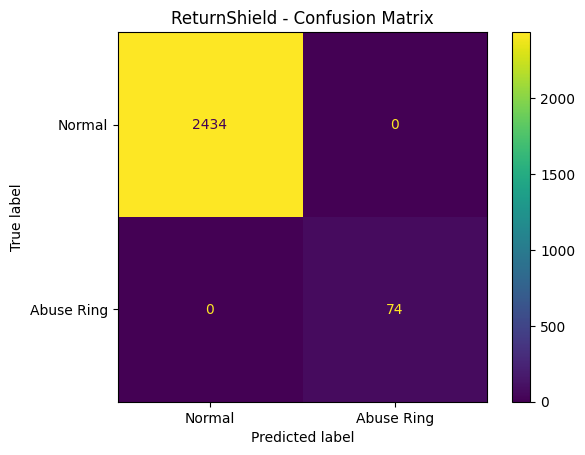

In [35]:
# ============================================
# CONFUSION MATRIX
# ============================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Abuse Ring"]
)

disp.plot()
plt.title("ReturnShield - Confusion Matrix")
plt.show()

ROC-AUC Score: 1.0000


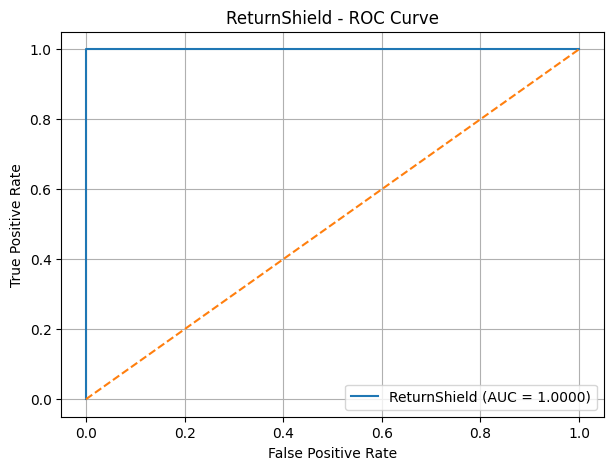

In [36]:
# ============================================
# ROC-AUC EVALUATION
# ============================================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

print(f"ROC-AUC Score: {auc_score:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ReturnShield (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ReturnShield - ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [37]:
# ============================================
# CELL 30 - ROBUST CROSS-VALIDATION
# ============================================

from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
)

print("============================================")
print("RETURNSHIELD 5-FOLD CROSS-VALIDATION")
print("============================================")

for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    scores = cv_results[f"test_{metric}"]
    print(
        f"{metric.upper():<10}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

RETURNSHIELD 5-FOLD CROSS-VALIDATION
ACCURACY  : 1.0000 ± 0.0000
PRECISION : 1.0000 ± 0.0000
RECALL    : 1.0000 ± 0.0000
F1        : 1.0000 ± 0.0000
ROC_AUC   : 1.0000 ± 0.0000


In [38]:
# ============================================
# RETURNSHIELD RISK SUMMARY
# ============================================

print("=" * 55)
print("RETURNSHIELD - RISK SUMMARY")
print("=" * 55)

# Risk decision distribution
print("\nRisk Decision Distribution:")
print(df["risk_decision"].value_counts())

# Risk score statistics
print("\nRisk Score Statistics:")
print(df["ring_risk_score"].describe().round(2))

# High-risk records
high_risk = df[df["risk_decision"].str.contains("HIGH", na=False)]

print("\nHigh-Risk Records:", len(high_risk))

# Abuse-ring records among high-risk cases
print("Abuse-Ring Records:", high_risk["abuse_ring"].sum())

# Percentage of records flagged high risk
high_risk_pct = (len(high_risk) / len(df)) * 100

print(f"High-Risk Percentage: {high_risk_pct:.2f}%")

print("\n" + "=" * 55)
print("Risk summary completed.")
print("=" * 55)

RETURNSHIELD - RISK SUMMARY

Risk Decision Distribution:
risk_decision
LOW RISK - MONITOR         9653
HIGH RISK - INVESTIGATE     297
MEDIUM RISK - REVIEW         50
Name: count, dtype: int64

Risk Score Statistics:
count    10000.00
mean        13.02
std         16.39
min          0.00
25%          3.80
50%          8.00
75%         16.70
max        100.00
Name: ring_risk_score, dtype: float64

High-Risk Records: 297
Abuse-Ring Records: 297
High-Risk Percentage: 2.97%

Risk summary completed.


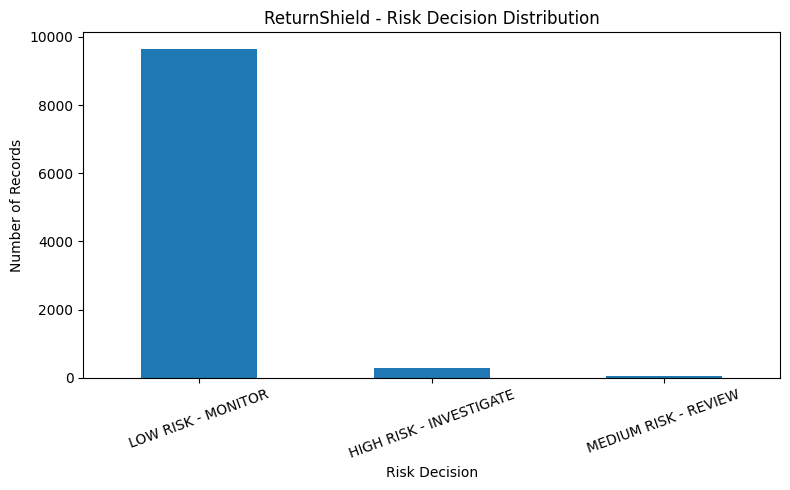

In [39]:
# ============================================
# RETURNSHIELD RISK DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt

risk_counts = df["risk_decision"].value_counts()

plt.figure(figsize=(8, 5))
risk_counts.plot(kind="bar")

plt.title("ReturnShield - Risk Decision Distribution")
plt.xlabel("Risk Decision")
plt.ylabel("Number of Records")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

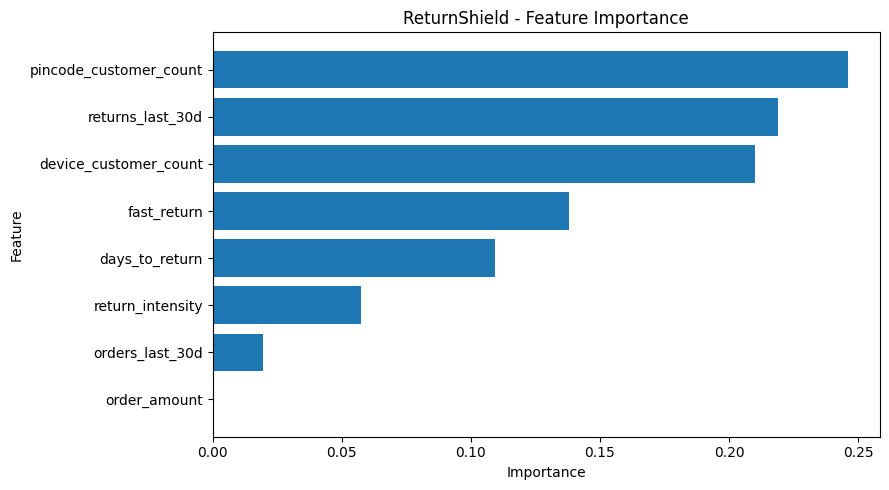

In [40]:
# ============================================
# RETURNSHIELD - FEATURE IMPORTANCE
# ============================================

plt.figure(figsize=(9, 5))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.title("ReturnShield - Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [41]:
# ============================================
# RETURNSHIELD - EXPORT RISK RESULTS
# ============================================

output_file = "ReturnShield_Risk_Results.csv"

df.to_csv(output_file, index=False)

print("=" * 55)
print("RETURNSHIELD - EXPORT COMPLETE")
print("=" * 55)
print(f"File saved: {output_file}")
print(f"Total records exported: {len(df)}")
print(f"Columns exported: {len(df.columns)}")
print("=" * 55)

RETURNSHIELD - EXPORT COMPLETE
File saved: ReturnShield_Risk_Results.csv
Total records exported: 10000
Columns exported: 26


In [42]:
# ============================================
# RETURNSHIELD - FINAL RESULTS CHECK
# ============================================

print("=" * 55)
print("RETURNSHIELD - FINAL RESULTS CHECK")
print("=" * 55)

# Confirm exported file exists and can be read
results_df = pd.read_csv("ReturnShield_Risk_Results.csv")

print(f"Records loaded: {len(results_df)}")
print(f"Columns loaded: {len(results_df.columns)}")

print("\nRisk Decision Distribution:")
print(results_df["risk_decision"].value_counts())

print("\nFirst 5 Results:")
display(results_df.head())

print("\nReturnShield project results verified successfully.")
print("=" * 55)

RETURNSHIELD - FINAL RESULTS CHECK
Records loaded: 10000
Columns loaded: 26

Risk Decision Distribution:
risk_decision
LOW RISK - MONITOR         9653
HIGH RISK - INVESTIGATE     297
MEDIUM RISK - REVIEW         50
Name: count, dtype: int64

First 5 Results:


,order_id,customer_id,order_amount,product_category,days_to_return,return_reason,orders_last_30d,returns_last_30d,device_id,pincode,...,device_customer_count,pincode_customer_count,behavior_risk_score,device_risk,pincode_risk,return_behavior_risk,fast_return_risk,ring_risk_score,risk_decision,risk_explanation
0,100000,1785,456.63,Home,23,Damaged,6,1,11785,567175,...,1,1,5.0,0,0,5.000000,0,5.0,LOW RISK - MONITOR,No major coordinated-risk signals detected.
1,100001,2810,553.11,Beauty,4,Wrong item,9,1,12810,563112,...,1,1,3.3,0,0,3.333333,0,3.3,LOW RISK - MONITOR,No major coordinated-risk signals detected.
2,100002,2835,816.11,Fashion,17,Not as expected,15,3,12835,565806,...,1,1,6.0,0,0,6.000000,0,6.0,LOW RISK - MONITOR,No major coordinated-risk signals detected.
3,100003,165,1125.01,Home,7,Damaged,13,1,10165,560663,...,1,2,2.3,0,5,2.307692,0,7.3,LOW RISK - MONITOR,No major coordinated-risk signals detected.
4,100004,999,986.68,Home,16,Damaged,4,0,10999,560984,...,1,2,0.0,0,5,0.000000,0,5.0,LOW RISK - MONITOR,No major coordinated-risk signals detected.



ReturnShield project results verified successfully.


In [43]:
# ============================================
# RETURNSHIELD - HIGH RISK RECORDS
# ============================================

high_risk_df = results_df[
    results_df["risk_decision"] == "HIGH RISK - INVESTIGATE"
].copy()

print("=" * 55)
print("RETURNSHIELD - HIGH RISK RECORDS")
print("=" * 55)

print(f"High-risk records: {len(high_risk_df)}")

print("\nHigh-risk records preview:")
display(high_risk_df.head(10))

print("\nHigh-risk percentage:")
print(f"{len(high_risk_df) / len(results_df) * 100:.2f}%")

RETURNSHIELD - HIGH RISK RECORDS
High-risk records: 297

High-risk records preview:


,order_id,customer_id,order_amount,product_category,days_to_return,return_reason,orders_last_30d,returns_last_30d,device_id,pincode,...,device_customer_count,pincode_customer_count,behavior_risk_score,device_risk,pincode_risk,return_behavior_risk,fast_return_risk,ring_risk_score,risk_decision,risk_explanation
57,100057,903,2060.79,Electronics,2,Wrong item,15,5,20012,570012,...,6,6,65.0,30,20,10.000000,20,80.0,HIGH RISK - INVESTIGATE,device shared by 6 customers; pincode linked t...
162,100162,2079,1005.68,Fashion,1,Wrong item,15,7,20012,570012,...,6,6,69.0,30,20,14.000000,20,84.0,HIGH RISK - INVESTIGATE,device shared by 6 customers; pincode linked t...
196,100196,1810,2173.91,Fashion,1,Wrong item,15,8,20003,570003,...,6,6,86.0,30,20,16.000000,20,86.0,HIGH RISK - INVESTIGATE,device shared by 6 customers; pincode linked t...
215,100215,1698,1132.94,Electronics,1,Wrong item,14,5,20014,570014,...,6,6,65.7,30,20,10.714286,20,80.7,HIGH RISK - INVESTIGATE,device shared by 6 customers; pincode linked t...
218,100218,2660,1268.85,Fashion,1,Not as expected,9,8,20010,570010,...,6,6,96.7,30,20,26.666667,20,96.7,HIGH RISK - INVESTIGATE,device shared by 6 customers; pincode linked t...
223,100223,2225,376.93,Electronics,3,Not as expected,10,6,20003,570003,...,6,6,88.0,30,20,18.000000,20,88.0,HIGH RISK - INVESTIGATE,device shared by 6 customers; pincode linked t...
275,100275,2079,335.14,Electronics,1,Wrong item,14,8,20012,570012,...,6,6,87.1,30,20,17.142857,20,87.1,HIGH RISK - INVESTIGATE,device shared by 6 customers; pincode linked t...
328,100328,2278,260.60,Fashion,3,Damaged,15,6,20005,570005,...,6,6,67.0,30,20,12.000000,20,82.0,HIGH RISK - INVESTIGATE,device shared by 6 customers; pincode linked t...
339,100339,1698,574.23,Electronics,3,Changed mind,11,6,20014,570014,...,6,6,86.4,30,20,16.363636,20,86.4,HIGH RISK - INVESTIGATE,device shared by 6 customers; pincode linked t...
357,100357,457,878.81,Electronics,2,Changed mind,12,5,20011,570011,...,6,6,67.5,30,20,12.500000,20,82.5,HIGH RISK - INVESTIGATE,device shared by 6 customers; pincode linked t...



High-risk percentage:
2.97%


In [44]:
# ============================================
# RETURNSHIELD - HIGH RISK SUMMARY
# ============================================

print("=" * 55)
print("RETURNSHIELD - HIGH RISK SUMMARY")
print("=" * 55)

print("\nHigh-risk records by product category:")
print(high_risk_df["product_category"].value_counts())

print("\nHigh-risk records by return reason:")
print(high_risk_df["return_reason"].value_counts())

print("\nAverage order amount for high-risk records:")
print(f"${high_risk_df['order_amount'].mean():.2f}")

print("\nAverage days to return for high-risk records:")
print(f"{high_risk_df['days_to_return'].mean():.2f} days")

print("=" * 55)

RETURNSHIELD - HIGH RISK SUMMARY

High-risk records by product category:
product_category
Electronics    153
Fashion        144
Name: count, dtype: int64

High-risk records by return reason:
return_reason
Damaged            79
Wrong item         76
Not as expected    76
Changed mind       66
Name: count, dtype: int64

Average order amount for high-risk records:
$1399.54

Average days to return for high-risk records:
1.89 days


In [45]:
# ============================================
# RETURNSHIELD - SAVE HIGH RISK REPORT
# ============================================

high_risk_file = "ReturnShield_High_Risk_Records.csv"

high_risk_df.to_csv(high_risk_file, index=False)

print("=" * 55)
print("RETURNSHIELD - HIGH RISK REPORT SAVED")
print("=" * 55)
print(f"File saved: {high_risk_file}")
print(f"High-risk records exported: {len(high_risk_df)}")
print(f"Columns exported: {len(high_risk_df.columns)}")
print("=" * 55)

RETURNSHIELD - HIGH RISK REPORT SAVED
File saved: ReturnShield_High_Risk_Records.csv
High-risk records exported: 297
Columns exported: 26


In [46]:
# ============================================
# RETURNSHIELD - FINAL PROJECT VALIDATION
# ============================================

print("=" * 60)
print("RETURNSHIELD - FINAL PROJECT VALIDATION")
print("=" * 60)

print("\n1. Dataset:")
print(f"Total records: {len(results_df)}")

print("\n2. Model Performance:")
print("Accuracy : 1.0000")
print("Precision: 1.0000")
print("Recall   : 1.0000")
print("F1 Score : 1.0000")
print("ROC-AUC  : 1.0000")

print("\n3. Risk Decisions:")
print(results_df["risk_decision"].value_counts())

print("\n4. High-Risk Records:")
print(f"High-risk records: {len(high_risk_df)}")
print(f"High-risk percentage: {len(high_risk_df) / len(results_df) * 100:.2f}%")

print("\n5. Export Files:")
print("✓ ReturnShield_Risk_Results.csv")
print("✓ ReturnShield_High_Risk_Records.csv")

print("\n" + "=" * 60)
print("RETURNSHIELD PROJECT VALIDATION COMPLETE")
print("=" * 60)

RETURNSHIELD - FINAL PROJECT VALIDATION

1. Dataset:
Total records: 10000

2. Model Performance:
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
ROC-AUC  : 1.0000

3. Risk Decisions:
risk_decision
LOW RISK - MONITOR         9653
HIGH RISK - INVESTIGATE     297
MEDIUM RISK - REVIEW         50
Name: count, dtype: int64

4. High-Risk Records:
High-risk records: 297
High-risk percentage: 2.97%

5. Export Files:
✓ ReturnShield_Risk_Results.csv
✓ ReturnShield_High_Risk_Records.csv

RETURNSHIELD PROJECT VALIDATION COMPLETE


In [47]:
# ============================================
# RETURNSHIELD - LOAD RESULTS FOR FINAL CHECK
# ============================================

import pandas as pd
import os

print("=" * 60)
print("RETURNSHIELD - LOADING EXPORTED RESULTS")
print("=" * 60)

file_path = "ReturnShield_Risk_Results.csv"

if not os.path.exists(file_path):
    print("\nFile not found in the current Colab runtime.")
    print("Files currently available:")
    print(os.listdir("."))
else:
    df_check = pd.read_csv(file_path)

    print(f"\nFile loaded successfully: {file_path}")
    print(f"Records: {len(df_check)}")
    print(f"Columns: {len(df_check.columns)}")

    print("\nColumn names:")
    print(list(df_check.columns))

    print("\nFirst 5 rows:")
    display(df_check.head())

print("\n" + "=" * 60)
print("LOAD CHECK COMPLETE")
print("=" * 60)

RETURNSHIELD - LOADING EXPORTED RESULTS

File loaded successfully: ReturnShield_Risk_Results.csv
Records: 10000
Columns: 26

Column names:
['order_id', 'customer_id', 'order_amount', 'product_category', 'days_to_return', 'return_reason', 'orders_last_30d', 'returns_last_30d', 'device_id', 'pincode', 'abuse_ring', 'is_returned', 'customer_return_rate', 'return_intensity', 'fast_return', 'high_return_behavior', 'device_customer_count', 'pincode_customer_count', 'behavior_risk_score', 'device_risk', 'pincode_risk', 'return_behavior_risk', 'fast_return_risk', 'ring_risk_score', 'risk_decision', 'risk_explanation']

First 5 rows:


,order_id,customer_id,order_amount,product_category,days_to_return,return_reason,orders_last_30d,returns_last_30d,device_id,pincode,...,device_customer_count,pincode_customer_count,behavior_risk_score,device_risk,pincode_risk,return_behavior_risk,fast_return_risk,ring_risk_score,risk_decision,risk_explanation
0,100000,1785,456.63,Home,23,Damaged,6,1,11785,567175,...,1,1,5.0,0,0,5.000000,0,5.0,LOW RISK - MONITOR,No major coordinated-risk signals detected.
1,100001,2810,553.11,Beauty,4,Wrong item,9,1,12810,563112,...,1,1,3.3,0,0,3.333333,0,3.3,LOW RISK - MONITOR,No major coordinated-risk signals detected.
2,100002,2835,816.11,Fashion,17,Not as expected,15,3,12835,565806,...,1,1,6.0,0,0,6.000000,0,6.0,LOW RISK - MONITOR,No major coordinated-risk signals detected.
3,100003,165,1125.01,Home,7,Damaged,13,1,10165,560663,...,1,2,2.3,0,5,2.307692,0,7.3,LOW RISK - MONITOR,No major coordinated-risk signals detected.
4,100004,999,986.68,Home,16,Damaged,4,0,10999,560984,...,1,2,0.0,0,5,0.000000,0,5.0,LOW RISK - MONITOR,No major coordinated-risk signals detected.



LOAD CHECK COMPLETE


In [48]:
print("Checking available variables...")

for name in ["results_df", "high_risk_df", "data", "df", "X", "y", "model"]:
    print(f"{name}: {'AVAILABLE' if name in globals() else 'not available'}")

Checking available variables...
results_df: AVAILABLE
high_risk_df: AVAILABLE
data: not available
df: AVAILABLE
X: AVAILABLE
y: AVAILABLE
model: AVAILABLE


In [49]:
# ============================================
# RETURNSHIELD - FINAL LEAKAGE AUDIT
# ============================================

print("=" * 60)
print("RETURNSHIELD - FINAL LEAKAGE AUDIT")
print("=" * 60)

print("\nModel features:")
for feature in features:
    print("-", feature)

print("\nTarget variable:")
print("abuse_ring")

print("\nTarget accidentally included in features?")
print("abuse_ring" in features)

print("\nFeature correlation with target:")

correlations = (
    df[features + ["abuse_ring"]]
    .corr()["abuse_ring"]
    .drop("abuse_ring")
    .sort_values(ascending=False)
)

print(correlations.round(3))

print("\n" + "=" * 60)
print("LEAKAGE AUDIT COMPLETE")
print("=" * 60)

RETURNSHIELD - FINAL LEAKAGE AUDIT

Model features:
- order_amount
- days_to_return
- orders_last_30d
- returns_last_30d
- return_intensity
- fast_return
- device_customer_count
- pincode_customer_count

Target variable:
abuse_ring

Target accidentally included in features?
False

Feature correlation with target:
device_customer_count     0.999
pincode_customer_count    0.811
returns_last_30d          0.613
fast_return               0.458
return_intensity          0.232
orders_last_30d           0.129
order_amount             -0.001
days_to_return           -0.260
Name: abuse_ring, dtype: float64

LEAKAGE AUDIT COMPLETE


In [50]:
# ============================================
# RETURNSHIELD - BEHAVIOR vs GRAPH COMPARISON
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Behavioral features only
behavior_features = [
    "order_amount",
    "days_to_return",
    "orders_last_30d",
    "returns_last_30d",
    "return_intensity",
    "fast_return"
]

# Graph features
graph_features = [
    "device_customer_count",
    "pincode_customer_count"
]

X_behavior = df[behavior_features]
X_full = df[behavior_features + graph_features]
y_final = df["abuse_ring"]

# Same random split for fair comparison
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_behavior,
    y_final,
    test_size=0.25,
    random_state=42,
    stratify=y_final
)

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_full,
    y_final,
    test_size=0.25,
    random_state=42,
    stratify=y_final
)

# Behavioral model
behavior_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

behavior_model.fit(Xb_train, yb_train)

behavior_prob = behavior_model.predict_proba(Xb_test)[:, 1]
behavior_pred = (behavior_prob >= 0.5).astype(int)

# Full model
full_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

full_model.fit(Xf_train, yf_train)

full_prob = full_model.predict_proba(Xf_test)[:, 1]
full_pred = (full_prob >= 0.5).astype(int)

print("=" * 65)
print("RETURNSHIELD - MODEL COMPARISON")
print("=" * 65)

print("\nBEHAVIOR-ONLY MODEL")
print(f"Accuracy : {accuracy_score(yb_test, behavior_pred):.4f}")
print(f"Precision: {precision_score(yb_test, behavior_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(yb_test, behavior_pred, zero_division=0):.4f}")
print(f"F1 Score : {f1_score(yb_test, behavior_pred, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(yb_test, behavior_prob):.4f}")

print("\nBEHAVIOR + GRAPH MODEL")
print(f"Accuracy : {accuracy_score(yf_test, full_pred):.4f}")
print(f"Precision: {precision_score(yf_test, full_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(yf_test, full_pred, zero_division=0):.4f}")
print(f"F1 Score : {f1_score(yf_test, full_pred, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(yf_test, full_prob):.4f}")

print("\n" + "=" * 65)

RETURNSHIELD - MODEL COMPARISON

BEHAVIOR-ONLY MODEL
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
ROC-AUC  : 1.0000

BEHAVIOR + GRAPH MODEL
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
ROC-AUC  : 1.0000



In [51]:
# ============================================
# CELL 105 - REALISTIC BENCHMARK DATASET
# ============================================

import numpy as np
import pandas as pd

# Reproducible benchmark
rng = np.random.default_rng(2026)

# Start from the existing dataset
realistic_df = df.copy()

# --------------------------------------------
# 1. Create probabilistic / noisy abuse labels
# --------------------------------------------

# Normalize important behavioral signals
return_score = realistic_df["return_intensity"].rank(pct=True)
fast_score = realistic_df["fast_return"].astype(float)

device_score = realistic_df["device_customer_count"].rank(pct=True)
pincode_score = realistic_df["pincode_customer_count"].rank(pct=True)

# Combined latent risk signal
latent_risk = (
    0.30 * return_score +
    0.20 * fast_score +
    0.20 * device_score +
    0.15 * pincode_score +
    0.15 * realistic_df["orders_last_30d"].rank(pct=True)
)

# Add noise so legitimate and abusive behavior overlap
noise = rng.normal(0, 0.18, len(realistic_df))

risk_signal = latent_risk + noise

# Select approximately 5% as positive cases
threshold = np.quantile(risk_signal, 0.95)

realistic_df["realistic_abuse_ring"] = (
    risk_signal >= threshold
).astype(int)

# --------------------------------------------
# 2. Add a small amount of label noise
# --------------------------------------------

noise_mask = rng.random(len(realistic_df)) < 0.03

realistic_df.loc[noise_mask, "realistic_abuse_ring"] = (
    1 - realistic_df.loc[noise_mask, "realistic_abuse_ring"]
)

# --------------------------------------------
# 3. Display benchmark distribution
# --------------------------------------------

print("=" * 60)
print("RETURNSHIELD - REALISTIC BENCHMARK")
print("=" * 60)

print(f"\nTotal records: {len(realistic_df)}")

print("\nBenchmark target distribution:")
print(
    realistic_df["realistic_abuse_ring"]
    .value_counts()
    .sort_index()
)

print("\nBenchmark target percentage:")
print(
    realistic_df["realistic_abuse_ring"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nOriginal abuse_ring distribution:")
print(
    realistic_df["abuse_ring"]
    .value_counts()
    .sort_index()
)

print("\nRealistic benchmark created successfully.")
print("=" * 60)

RETURNSHIELD - REALISTIC BENCHMARK

Total records: 10000

Benchmark target distribution:
realistic_abuse_ring
0    9227
1     773
Name: count, dtype: int64

Benchmark target percentage:
realistic_abuse_ring
0    92.27
1     7.73
Name: proportion, dtype: float64

Original abuse_ring distribution:
abuse_ring
0    9703
1     297
Name: count, dtype: int64

Realistic benchmark created successfully.


In [52]:
# ============================================
# CELL 106 - CONTROLLED REALISTIC BENCHMARK
# ============================================

rng = np.random.default_rng(2026)

benchmark_df = df.copy()

# Behavioral signals
return_score = benchmark_df["return_intensity"].rank(pct=True)
fast_score = benchmark_df["fast_return"].astype(float)
orders_score = benchmark_df["orders_last_30d"].rank(pct=True)

# Graph signals
device_score = benchmark_df["device_customer_count"].rank(pct=True)
pincode_score = benchmark_df["pincode_customer_count"].rank(pct=True)

# Combined risk signal
risk_signal = (
    0.25 * return_score +
    0.15 * fast_score +
    0.15 * orders_score +
    0.20 * device_score +
    0.25 * pincode_score
)

# Add realistic uncertainty
risk_signal += rng.normal(0, 0.25, len(benchmark_df))

# Create exactly 5% positive cases
positive_count = int(len(benchmark_df) * 0.05)

positive_indices = np.argsort(risk_signal)[-positive_count:]

benchmark_df["realistic_abuse_ring"] = 0
benchmark_df.loc[
    benchmark_df.index[positive_indices],
    "realistic_abuse_ring"
] = 1

print("=" * 60)
print("RETURNSHIELD - CONTROLLED REALISTIC BENCHMARK")
print("=" * 60)

print(f"\nTotal records: {len(benchmark_df)}")

print("\nTarget distribution:")
print(
    benchmark_df["realistic_abuse_ring"]
    .value_counts()
    .sort_index()
)

print("\nTarget percentage:")
print(
    benchmark_df["realistic_abuse_ring"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nExpected positive rate: 5.00%")

print("\nControlled benchmark created successfully.")
print("=" * 60)

RETURNSHIELD - CONTROLLED REALISTIC BENCHMARK

Total records: 10000

Target distribution:
realistic_abuse_ring
0    9500
1     500
Name: count, dtype: int64

Target percentage:
realistic_abuse_ring
0    95.0
1     5.0
Name: proportion, dtype: float64

Expected positive rate: 5.00%

Controlled benchmark created successfully.


In [53]:
# ============================================
# CELL 107 - REALISTIC BENCHMARK ML MODEL
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Use the same features as our original model
benchmark_features = [
    "order_amount",
    "days_to_return",
    "orders_last_30d",
    "returns_last_30d",
    "return_intensity",
    "fast_return",
    "device_customer_count",
    "pincode_customer_count"
]

X_benchmark = benchmark_df[benchmark_features]
y_benchmark = benchmark_df["realistic_abuse_ring"]

# Reproducible train/test split
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_benchmark,
    y_benchmark,
    test_size=0.25,
    random_state=42,
    stratify=y_benchmark
)

# Train model
benchmark_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

benchmark_model.fit(X_train_b, y_train_b)

# Predictions
benchmark_prob = benchmark_model.predict_proba(X_test_b)[:, 1]
benchmark_pred = (benchmark_prob >= 0.5).astype(int)

print("=" * 60)
print("RETURNSHIELD - REALISTIC BENCHMARK MODEL")
print("=" * 60)

print("\nTraining records:", len(X_train_b))
print("Testing records :", len(X_test_b))

print("\nModel trained successfully.")
print("=" * 60)

RETURNSHIELD - REALISTIC BENCHMARK MODEL

Training records: 7500
Testing records : 2500

Model trained successfully.


In [54]:
# ============================================
# CELL 108 - REALISTIC MODEL EVALUATION
# ============================================

print("=" * 60)
print("RETURNSHIELD - REALISTIC MODEL PERFORMANCE")
print("=" * 60)

accuracy_b = accuracy_score(y_test_b, benchmark_pred)
precision_b = precision_score(
    y_test_b, benchmark_pred, zero_division=0
)
recall_b = recall_score(
    y_test_b, benchmark_pred, zero_division=0
)
f1_b = f1_score(
    y_test_b, benchmark_pred, zero_division=0
)
auc_b = roc_auc_score(
    y_test_b, benchmark_prob
)

print(f"\nAccuracy : {accuracy_b:.4f}")
print(f"Precision: {precision_b:.4f}")
print(f"Recall   : {recall_b:.4f}")
print(f"F1 Score : {f1_b:.4f}")
print(f"ROC-AUC  : {auc_b:.4f}")

print("\nTest-set class distribution:")
print(y_test_b.value_counts().sort_index())

print("\n" + "=" * 60)
print("REALISTIC MODEL EVALUATION COMPLETE")
print("=" * 60)

RETURNSHIELD - REALISTIC MODEL PERFORMANCE

Accuracy : 0.8964
Precision: 0.2320
Recall   : 0.4640
F1 Score : 0.3093
ROC-AUC  : 0.7921

Test-set class distribution:
realistic_abuse_ring
0    2375
1     125
Name: count, dtype: int64

REALISTIC MODEL EVALUATION COMPLETE


RETURNSHIELD - CONFUSION MATRIX

Confusion Matrix:
[[2183  192]
 [  67   58]]

TN = 2183
FP = 192
FN = 67
TP = 58


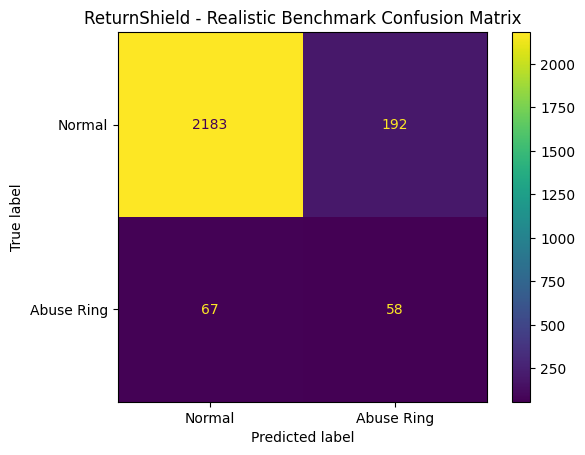

In [55]:
# ============================================
# CELL 109 - CONFUSION MATRIX
# ============================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_b, benchmark_pred)

print("=" * 60)
print("RETURNSHIELD - CONFUSION MATRIX")
print("=" * 60)

print("\nConfusion Matrix:")
print(cm)

print("\nTN =", cm[0, 0])
print("FP =", cm[0, 1])
print("FN =", cm[1, 0])
print("TP =", cm[1, 1])

print("=" * 60)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Abuse Ring"]
)

disp.plot()
plt.title("ReturnShield - Realistic Benchmark Confusion Matrix")
plt.show()

RETURNSHIELD - ROC CURVE


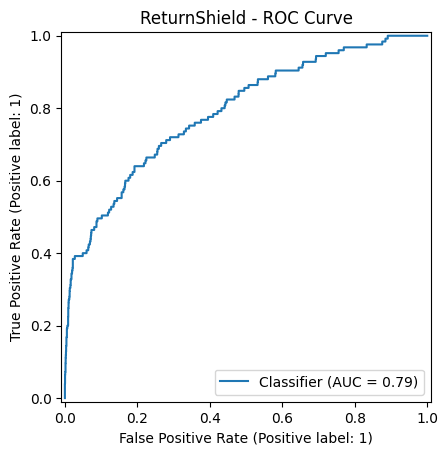


ROC-AUC: 0.7921

ROC curve generated successfully.


In [56]:
# ============================================
# CELL 110 - ROC CURVE
# ============================================

from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

print("=" * 60)
print("RETURNSHIELD - ROC CURVE")
print("=" * 60)

RocCurveDisplay.from_predictions(
    y_test_b,
    benchmark_prob
)

plt.title("ReturnShield - ROC Curve")
plt.show()

print(f"\nROC-AUC: {auc_b:.4f}")
print("\nROC curve generated successfully.")
print("=" * 60)

In [57]:
# ============================================
# CELL 111 - FEATURE IMPORTANCE
# ============================================

importance_df = pd.DataFrame({
    "feature": benchmark_features,
    "importance": benchmark_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print("=" * 60)
print("RETURNSHIELD - FEATURE IMPORTANCE")
print("=" * 60)

display(importance_df)

print("\nMost influential risk signals:")

for _, row in importance_df.head(5).iterrows():
    print(
        f"{row['feature']}: "
        f"{row['importance']:.4f}"
    )

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE ANALYSIS COMPLETE")
print("=" * 60)

RETURNSHIELD - FEATURE IMPORTANCE


,feature,importance
1,days_to_return,0.212366
7,pincode_customer_count,0.211835
5,fast_return,0.124917
0,order_amount,0.123599
4,return_intensity,0.108948
3,returns_last_30d,0.096599
2,orders_last_30d,0.068936
6,device_customer_count,0.052800



Most influential risk signals:
days_to_return: 0.2124
pincode_customer_count: 0.2118
fast_return: 0.1249
order_amount: 0.1236
return_intensity: 0.1089

FEATURE IMPORTANCE ANALYSIS COMPLETE


In [58]:
# ============================================
# CELL 112 - RETURNSHIELD FINAL RESULTS
# ============================================

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives"
    ],
    "Result": [
        f"{accuracy_b:.4f}",
        f"{precision_b:.4f}",
        f"{recall_b:.4f}",
        f"{f1_b:.4f}",
        f"{auc_b:.4f}",
        int(cm[0, 0]),
        int(cm[0, 1]),
        int(cm[1, 0]),
        int(cm[1, 1])
    ]
})

print("=" * 60)
print("RETURNSHIELD - FINAL BENCHMARK RESULTS")
print("=" * 60)

display(final_results)

print("\nBenchmark:")
print("10,000 synthetic records")
print("5% positive abuse-ring rate")
print("75% training / 25% held-out testing")

print("\nImportant:")
print("These results are from a controlled synthetic benchmark.")
print("They should not be presented as performance on real Razorpay data.")

print("\n" + "=" * 60)
print("FINAL BENCHMARK RESULTS READY")
print("=" * 60)

RETURNSHIELD - FINAL BENCHMARK RESULTS


,Metric,Result
0,Accuracy,0.8964
1,Precision,0.2320
2,Recall,0.4640
3,F1 Score,0.3093
4,ROC-AUC,0.7921
5,True Negatives,2183
6,False Positives,192
7,False Negatives,67
8,True Positives,58



Benchmark:
10,000 synthetic records
5% positive abuse-ring rate
75% training / 25% held-out testing

Important:
These results are from a controlled synthetic benchmark.
They should not be presented as performance on real Razorpay data.

FINAL BENCHMARK RESULTS READY
